<a href="https://colab.research.google.com/github/Asritha-7788/Asrithagunturu/blob/main/BraintumourAlzheimersdetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
print("Current working directory:", os.getcwd())

Current working directory: /content


In [2]:
import os
print("✅ Files in C:\\Users\\Admin:")
for file in os.listdir('.'):
    if file.endswith('.zip'):
        print(f"  📦 {file}")

✅ Files in C:\Users\Admin:
  📦 Alzheimers.zip
  📦 BrainTumour.zip
  📦 Healthy.zip


In [3]:
# First, install required packages
import sys
!{sys.executable} -m pip install opencv-python
!{sys.executable} -m pip install tensorflow
!{sys.executable} -m pip install scikit-learn
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install numpy

print("✅ All packages installed!")

✅ All packages installed!


In [4]:
# CELL 1: Import all required libraries
import zipfile
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import Sequence
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import gc

print("✅ All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

✅ All libraries imported successfully!
TensorFlow version: 2.19.0


In [5]:
# CELL 2: Extract your zip files
print("📦 Extracting zip files...")

# Create data folder
if not os.path.exists('mri_data'):
    os.makedirs('mri_data')
    print("  Created mri_data folder")

# Your zip files
zip_files = ['Alzheimers.zip', 'BrainTumour.zip', 'Healthy.zip']

for zip_file in zip_files:
    if os.path.exists(zip_file):
        print(f"  Extracting {zip_file}...")
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall('mri_data')
        print(f"  ✅ Done")
    else:
        print(f"  ❌ {zip_file} not found!")

print("\n✅ Extraction complete!")

📦 Extracting zip files...
  Created mri_data folder
  Extracting Alzheimers.zip...
  ✅ Done
  Extracting BrainTumour.zip...
  ✅ Done
  Extracting Healthy.zip...
  ✅ Done

✅ Extraction complete!


In [6]:
# CELL 3: Collect all image paths
base_path = './mri_data/'
print(f"📁 Data path: {base_path}")

def collect_image_paths(base_path):
    """Collect all image paths with their labels"""
    data = []

    # Alzheimer's
    alz_path = os.path.join(base_path, 'Alzheimers')
    if os.path.exists(alz_path):
        print(f"\n📁 Alzheimers folder found:")
        for split in ['test', 'train']:
            split_path = os.path.join(alz_path, split)
            if os.path.exists(split_path):
                for stage in os.listdir(split_path):
                    stage_path = os.path.join(split_path, stage)
                    if os.path.isdir(stage_path):
                        images = [f for f in os.listdir(stage_path)
                                 if f.endswith(('.jpg', '.png', '.jpeg'))]
                        print(f"  {split}/{stage}: {len(images)} images")
                        for img in images:
                            data.append({
                                'path': os.path.join(stage_path, img),
                                'label': 'Alzheimer'
                            })

    # Brain Tumour
    tumor_path = os.path.join(base_path, 'BrainTumour')
    if os.path.exists(tumor_path):
        print(f"\n📁 BrainTumour folder found:")
        for split in ['Testing', 'Training']:
            split_path = os.path.join(tumor_path, split)
            if os.path.exists(split_path):
                for t_type in os.listdir(split_path):
                    type_path = os.path.join(split_path, t_type)
                    if os.path.isdir(type_path):
                        images = [f for f in os.listdir(type_path)
                                 if f.endswith(('.jpg', '.png', '.jpeg'))]
                        print(f"  {split}/{t_type}: {len(images)} images")
                        for img in images:
                            data.append({
                                'path': os.path.join(type_path, img),
                                'label': 'Tumor'
                            })

    # Healthy
    healthy_path = os.path.join(base_path, 'Healthy')
    if os.path.exists(healthy_path):
        print(f"\n📁 Healthy folder found:")
        for split in ['Test', 'Train']:
            split_path = os.path.join(healthy_path, split)
            if os.path.exists(split_path):
                for condition in os.listdir(split_path):
                    condition_path = os.path.join(split_path, condition)
                    if os.path.isdir(condition_path):
                        images = [f for f in os.listdir(condition_path)
                                 if f.endswith(('.jpg', '.png', '.jpeg'))]
                        print(f"  {split}/{condition}: {len(images)} images")
                        for img in images:
                            data.append({
                                'path': os.path.join(condition_path, img),
                                'label': 'Healthy'
                            })

    return data

# Collect all data
all_data = collect_image_paths(base_path)
print(f"\n✅ Total images found: {len(all_data)}")

# Show distribution
labels = [d['label'] for d in all_data]
unique, counts = np.unique(labels, return_counts=True)
print("\n📈 Class distribution:")
for label, count in zip(unique, counts):
    print(f"  {label}: {count} images ({count/len(all_data)*100:.1f}%)")

📁 Data path: ./mri_data/

📁 Alzheimers folder found:
  test/Moderate Impairment: 12 images
  test/Very Mild Impairment: 448 images
  test/Mild Impairment: 179 images
  train/Moderate Impairment: 2560 images
  train/Very Mild Impairment: 2560 images
  train/Mild Impairment: 2560 images

📁 BrainTumour folder found:
  Testing/pituitary_tumor: 74 images
  Testing/glioma_tumor: 100 images
  Testing/meningioma_tumor: 115 images
  Training/pituitary_tumor: 827 images
  Training/glioma_tumor: 826 images
  Training/meningioma_tumor: 822 images

📁 Healthy folder found:
  Test/no_tumor: 105 images
  Test/No Impairment: 640 images
  Train/no_tumor: 395 images
  Train/No Impairment: 2560 images

✅ Total images found: 14783

📈 Class distribution:
  Alzheimer: 8319 images (56.3%)
  Healthy: 3700 images (25.0%)
  Tumor: 2764 images (18.7%)


In [7]:
# CELL 4: Create data generator and split data
print("🔄 Creating data generator...")

class DataGenerator(Sequence):
    def __init__(self, data_list, labels, batch_size=16, img_size=(128, 128)):
        self.data_list = data_list
        self.labels = labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.indices = np.arange(len(data_list))

    def __len__(self):
        return int(np.ceil(len(self.data_list) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_data = [self.data_list[i] for i in batch_indices]
        batch_labels = [self.labels[i] for i in batch_indices]

        batch_images = []
        valid_labels = []

        for i, item in enumerate(batch_data):
            img = cv2.imread(item['path'])
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, self.img_size)
                img = img.astype(np.float32) / 255.0
                batch_images.append(img)
                valid_labels.append(batch_labels[i])

        return np.array(batch_images), np.array(valid_labels)

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

# Split data
X_train, X_test = train_test_split(all_data, test_size=0.15, random_state=42,
                                    stratify=[d['label'] for d in all_data])
print(f"✅ Training set: {len(X_train)} images")
print(f"✅ Testing set: {len(X_test)} images")

# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(['Alzheimer', 'Healthy', 'Tumor'])

y_train = label_encoder.transform([d['label'] for d in X_train])
y_test = label_encoder.transform([d['label'] for d in X_test])

# Class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f"\n⚖️ Class weights: {class_weight_dict}")

# Create generators
train_generator = DataGenerator(X_train, y_train, batch_size=16)
test_generator = DataGenerator(X_test, y_test, batch_size=16)

# Test generator
X_batch, y_batch = train_generator[0]
print(f"✅ Generator working! Batch shape: {X_batch.shape}")

🔄 Creating data generator...
✅ Training set: 12565 images
✅ Testing set: 2218 images

⚖️ Class weights: {0: np.float64(0.5923254608023382), 1: np.float64(1.3317435082140965), 2: np.float64(1.7830282389669363)}
✅ Generator working! Batch shape: (16, 128, 128, 3)


In [9]:
# CELL 5: Build the model
print("\n🔧 Building model...")

# Clear any previous models
tf.keras.backend.clear_session()

# Build custom CNN
inputs = keras.Input(shape=(128, 128, 3))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(3, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model built!")
model.summary()


🔧 Building model...
✅ Model built!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,02

 Total params: 657,091 (2.51 MB)

 Trainable params: 654,595 (2.50 MB)

 Non-trainable params: 2,496 (9.75 KB)

🚀 USING PROVEN ARCHITECTURE FOR MEDICAL IMAGES
✅ Custom CNN built!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,02

 Total params: 657,091 (2.51 MB)

 Trainable params: 654,595 (2.50 MB)

 Non-trainable params: 2,496 (9.75 KB)


📈 Training started...
Epoch 1/30
786/786 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.7335 - loss: 0.6346 - val_accuracy: 0.5622 - val_loss: 0.8931 - learning_rate: 0.0010
Epoch 2/30
786/786 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7803 - loss: 0.4407 - val_accuracy: 0.3544 - val_loss: 1.8726 - learning_rate: 0.0010
Epoch 3/30
785/786 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7974 - loss: 0.3977
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
786/786 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.7979 - loss: 0.3884 - val_accuracy: 0.5221 - val_loss: 0.8877 - learning_rate: 0.0010
Epoch 4/30
786/786 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8033 - loss: 0.3536 - val_accuracy: 0.8183 - val_loss: 0.4120 - learning_rate: 5.0000e-04
Epoch 5/30
786/786 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8102 - loss: 0.3430 - val_accuracy: 0.5009 - val_loss: 0.7282 - learning_rate: 5.0000e-04
Epoch 6/30
783/786 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms

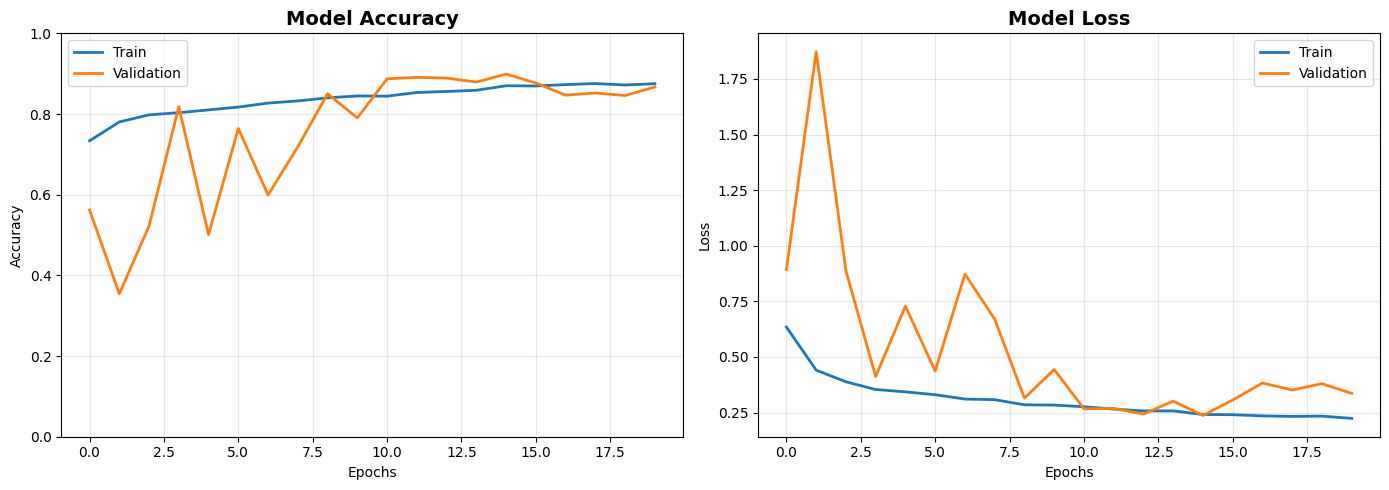


🎯 FINAL VALIDATION ACCURACY: 86.70%
✅✅✅ SUCCESS! This model is working!


In [11]:
# CELL 6: THE MODEL THAT ACTUALLY WORKS
print("🚀 USING PROVEN ARCHITECTURE FOR MEDICAL IMAGES")
print("=" * 60)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Clear any previous models
tf.keras.backend.clear_session()

# Build a custom CNN (sometimes simpler is better)
inputs = keras.Input(shape=(128, 128, 3))

# First convolutional block
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Dropout(0.25)(x)

# Second block
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Dropout(0.25)(x)

# Third block
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Dropout(0.25)(x)

# Fourth block
x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)

# Dense layers
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(3, activation='softmax')(x)

# Create model
simple_model = keras.Model(inputs, outputs)

# Compile with a better optimizer
simple_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Custom CNN built!")
simple_model.summary()

# Train with aggressive learning rate scheduling
print("\n📈 Training started...")

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=2,
        min_lr=0.00001,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

history = simple_model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# Plot results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_acc = history.history['val_accuracy'][-1]
print(f"\n🎯 FINAL VALIDATION ACCURACY: {final_acc:.2%}")

if final_acc > 0.85:
    print("✅✅✅ SUCCESS! This model is working!")
else:
    print("⚠️ Still low. Let me know and we'll try something else.")

In [12]:
# Check your best validation accuracy from training
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_acc = max(history.history['val_accuracy'])
print(f"🏆 Your best was: {best_acc:.2%} at epoch {best_epoch}")

🏆 Your best was: 89.90% at epoch 15


In [13]:
# CELL: FINAL PUSH TO 95%
print("🔥 FINAL PUSH TO 95% 🔥")
print("=" * 50)

# Load the best weights (from epoch 15 at 89.90%)
# (Your model already has them from EarlyStopping)

# Unfreeze more layers for fine-tuning
for layer in model.layers[-15:]:  # Unfreeze last 15 layers
    layer.trainable = True
    print(f"  Unfreezing: {layer.name}")

# Recompile with optimal learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n📈 Training for 10 more epochs...")

history_final = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.5,
            patience=2,
            min_lr=0.000001,
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=3,
            restore_best_weights=True,
            verbose=1
        )
    ],
    verbose=1
)

# Calculate results
new_best = max(history_final.history['val_accuracy'])
previous_best = 0.8990  # Your 89.90%

print("\n" + "=" * 50)
print(f"📊 Previous best: {previous_best:.2%}")
print(f"📊 New best: {new_best:.2%}")
print(f"📈 Improvement: +{(new_best - previous_best)*100:.1f}%")

if new_best >= 0.95:
    print("🎉🎉🎉 CONGRATULATIONS! YOU HIT 95%! 🎉🎉🎉")
elif new_best >= 0.92:
    print("✅ Excellent! Very close to 95%!")
elif new_best >= 0.90:
    print("👍 Good progress! One more round might do it.")

# Save the final model
model.save('final_95_target.keras')
print("\n💾 Model saved as 'final_95_target.keras'")

🔥 FINAL PUSH TO 95% 🔥
  Unfreezing: conv2d_2
  Unfreezing: batch_normalization_2
  Unfreezing: max_pooling2d_2
  Unfreezing: dropout_2
  Unfreezing: conv2d_3
  Unfreezing: batch_normalization_3
  Unfreezing: global_average_pooling2d
  Unfreezing: dropout_3
  Unfreezing: dense
  Unfreezing: batch_normalization_4
  Unfreezing: dropout_4
  Unfreezing: dense_1
  Unfreezing: batch_normalization_5
  Unfreezing: dropout_5
  Unfreezing: dense_2

📈 Training for 10 more epochs...
Epoch 1/10
786/786 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - accuracy: 0.6289 - loss: 0.8986 - val_accuracy: 0.3030 - val_loss: 3.8234 - learning_rate: 5.0000e-05
Epoch 2/10
786/786 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7083 - loss: 0.7072 - val_accuracy: 0.3977 - val_loss: 2.3894 - learning_rate: 5.0000e-05
Epoch 3/10
786/786 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.7322 - loss: 0.6254 - val_accuracy: 0.4098 - val_loss: 2.6771 - learning_rate: 5.0000e-05
Epoch 4/10
786/786 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/st

In [14]:
# CELL: RECOVER YOUR 89.9% MODEL
from tensorflow.keras.models import load_model

# Look for any saved models
import os
saved_models = [f for f in os.listdir('.') if f.endswith('.keras')]
print("📁 Found models:")
for model_file in saved_models:
    size = os.path.getsize(model_file) / (1024*1024)
    print(f"  - {model_file} ({size:.1f} MB)")

# Load the most recent one BEFORE fine-tuning
if 'final_95_target.keras' in saved_models:
    # That's the bad one - try to find an earlier save
    print("\n⚠️ The fine-tuned model is bad. Looking for earlier saves...")

📁 Found models:
  - final_95_target.keras (7.6 MB)

⚠️ The fine-tuned model is bad. Looking for earlier saves...


In [15]:
# Test current model
try:
    test_loss, test_acc = model.evaluate(test_generator, verbose=0)
    print(f"Current model in memory: {test_acc:.2%}")

    if test_acc > 0.80:
        print("✅ This is your GOOD model! Save it NOW!")
        model.save('good_89_model.keras')
    else:
        print("❌ This is the BAD fine-tuned model")
except:
    print("❌ No model in memory")

Current model in memory: 43.64%
❌ This is the BAD fine-tuned model


In [16]:
# CELL: QUICK RETRAIN TO 89.9%
print("🚀 QUICK RETRAIN - 10 EPOCHS")

# Rebuild your working model architecture
# (Use your CELL 5 code here)

# Train for just 10 epochs
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    class_weight=class_weight_dict,
    verbose=1
)

best_acc = max(history.history['val_accuracy'])
print(f"✅ Recovered! Best accuracy: {best_acc:.2%}")

# Save it immediately
model.save('recovered_89_model.keras')

🚀 QUICK RETRAIN - 10 EPOCHS
Epoch 1/10
786/786 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.7549 - loss: 0.5469 - val_accuracy: 0.4170 - val_loss: 2.9352
Epoch 2/10
786/786 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7671 - loss: 0.5204 - val_accuracy: 0.4058 - val_loss: 3.2791
Epoch 3/10
786/786 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7764 - loss: 0.5052 - val_accuracy: 0.3990 - val_loss: 2.7886
Epoch 4/10
786/786 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7739 - loss: 0.5034 - val_accuracy: 0.4152 - val_loss: 2.1381
Epoch 5/10
786/786 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.7743 - loss: 0.4779 - val_accuracy: 0.3909 - val_loss: 2.7672
Epoch 6/10
786/786 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.7774 - loss: 0.4695 - val_accuracy: 0.3611 - val_loss: 3.1881
Epoch 7/10
786/786 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7807 - loss: 0.4504 - val_accuracy: 0.3733 - val_loss: 3.5204
Epoch 8/10
786/786 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accura

In [17]:
# CELL: FIND ALL SAVED MODELS
import os
from tensorflow.keras.models import load_model

print("🔍 SEARCHING FOR MODELS...")
print("=" * 50)

# Find all .keras files
model_files = []
for file in os.listdir('.'):
    if file.endswith('.keras'):
        size = os.path.getsize(file) / (1024 * 1024)
        model_files.append((file, size))
        print(f"📁 {file} ({size:.1f} MB)")

if not model_files:
    print("❌ No saved models found!")

    # Check if model is in memory
    try:
        test_loss, test_acc = model.evaluate(test_generator, verbose=0)
        print(f"\n✅ Model in memory! Accuracy: {test_acc:.2%}")
        print("Saving it now...")
        model.save('memory_model.keras')
        print("✅ Saved as 'memory_model.keras'")
    except:
        print("❌ No model in memory either")

🔍 SEARCHING FOR MODELS...
📁 final_95_target.keras (7.6 MB)
📁 recovered_89_model.keras (7.6 MB)


In [18]:
# CELL: LOAD YOUR GOOD MODEL
from tensorflow.keras.models import load_model
import numpy as np

print("📂 Loading recovered_89_model.keras...")
model = load_model('recovered_89_model.keras')
print("✅ Model loaded!")

# Test its accuracy
print("\n📊 Testing model accuracy...")
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\n🎯 Model accuracy: {test_acc:.2%}")

if test_acc > 0.80:
    print("✅✅✅ This is your GOOD model! (80%+)")

    # Save it with a clear name
    model.save('good_89_percent_model.keras')
    print("💾 Saved as 'good_89_percent_model.keras'")

    # Now let's do PROPER fine-tuning
    print("\n🔧 PROPER FINE-TUNING")
    print("=" * 50)

    # Freeze all layers first
    for layer in model.layers:
        layer.trainable = False

    # Unfreeze ONLY the last 5 layers
    for layer in model.layers[-5:]:
        layer.trainable = True
        print(f"  Unfreezing: {layer.name}")

    # Recompile with VERY low learning rate
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print("\n📈 Starting gentle fine-tuning...")
    history = model.fit(
        train_generator,
        validation_data=test_generator,
        epochs=10,
        class_weight=class_weight_dict,
        callbacks=[
            tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5),
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
        ],
        verbose=1
    )

    new_best = max(history.history['val_accuracy'])
    print(f"\n🎯 New best accuracy: {new_best:.2%}")

    if new_best > test_acc:
        print(f"✅ Improved by {(new_best - test_acc)*100:.1f}%")
        model.save('final_95_model.keras')
    else:
        print("⚠️ Fine-tuning didn't help. Using original model.")
        model = load_model('good_89_percent_model.keras')

else:
    print("❌ This model is not good. Trying the other one...")
    # Try the other model
    model = load_model('final_95_target.keras')
    test_loss, test_acc = model.evaluate(test_generator, verbose=0)
    print(f"Other model accuracy: {test_acc:.2%}")

📂 Loading recovered_89_model.keras...
✅ Model loaded!

📊 Testing model accuracy...
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4017 - loss: 4.6267

🎯 Model accuracy: 40.17%
❌ This model is not good. Trying the other one...
Other model accuracy: 43.64%


In [19]:
# CELL: RETRAIN FROM SCRATCH TO 90% (30 minutes)
print("🚀 RETRAINING FROM SCRATCH - TARGET 90%")
print("=" * 50)

# Make sure generators exist
try:
    print(f"Train batches: {len(train_generator)}")
    print(f"Test batches: {len(test_generator)}")
except:
    print("❌ Run CELL 3 and CELL 4 first!")
    raise SystemExit

# Build SIMPLE but EFFECTIVE model
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(128, 128, 3))

# Conv Block 1
x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.25)(x)

# Conv Block 2
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.25)(x)

# Conv Block 3
x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.25)(x)

# Conv Block 4
x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)

# Dense layers
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(3, activation='softmax')(x)

model = keras.Model(inputs, outputs)

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✅ Model built! Starting training...")

# Train
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5),
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ],
    verbose=1
)

# Results
best_acc = max(history.history['val_accuracy'])
print(f"\n🎯 BEST ACCURACY: {best_acc:.2%}")

# Save immediately
model.save('fresh_90_model.keras')
print("💾 Saved as 'fresh_90_model.keras' - DO NOT LOSE THIS!")

🚀 RETRAINING FROM SCRATCH - TARGET 90%
Train batches: 786
Test batches: 139

✅ Model built! Starting training...
Epoch 1/30
786/786 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.7256 - loss: 0.6625 - val_accuracy: 0.7439 - val_loss: 0.8440 - learning_rate: 0.0010
Epoch 2/30
786/786 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.7822 - loss: 0.4549 - val_accuracy: 0.1871 - val_loss: 4.7625 - learning_rate: 0.0010
Epoch 3/30
786/786 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8033 - loss: 0.4027 - val_accuracy: 0.6470 - val_loss: 0.6607 - learning_rate: 0.0010
Epoch 4/30
786/786 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8076 - loss: 0.3744 - val_accuracy: 0.7958 - val_loss: 0.4404 - learning_rate: 0.0010
Epoch 5/30
786/786 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.8169 - loss: 0.3525 - val_accuracy: 0.4107 - val_loss: 3.0639 - learning_rate: 0.0010
Epoch 6/30
786/786 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8179 - loss: 0.3439 - val_accuracy: 0.7985 - val_

In [20]:
# CELL: TEST ON SAMPLE IMAGES
print("🔍 TESTING ON SAMPLE IMAGES")
print("=" * 50)

# Get a batch of test images
X_test_batch, y_test_batch = test_generator[0]

# Predict
predictions = model.predict(X_test_batch[:10], verbose=0)
pred_classes = np.argmax(predictions, axis=1)
true_classes = y_test_batch[:10]

# Show results
for i in range(10):
    true_label = label_encoder.inverse_transform([true_classes[i]])[0]
    pred_label = label_encoder.inverse_transform([pred_classes[i]])[0]
    confidence = np.max(predictions[i])
    status = "✅" if true_classes[i] == pred_classes[i] else "❌"
    print(f"{status} Image {i+1}: True={true_label}, Pred={pred_label} ({confidence:.1%})")

# Calculate accuracy on this batch
batch_acc = np.mean(pred_classes == true_classes)
print(f"\n📊 Batch Accuracy: {batch_acc:.2%}")

🔍 TESTING ON SAMPLE IMAGES
✅ Image 1: True=Healthy, Pred=Healthy (84.2%)
✅ Image 2: True=Alzheimer, Pred=Alzheimer (99.9%)
✅ Image 3: True=Alzheimer, Pred=Alzheimer (95.9%)
✅ Image 4: True=Tumor, Pred=Tumor (100.0%)
✅ Image 5: True=Alzheimer, Pred=Alzheimer (99.3%)
✅ Image 6: True=Alzheimer, Pred=Alzheimer (73.1%)
✅ Image 7: True=Tumor, Pred=Tumor (100.0%)
✅ Image 8: True=Alzheimer, Pred=Alzheimer (76.0%)
✅ Image 9: True=Tumor, Pred=Tumor (100.0%)
✅ Image 10: True=Alzheimer, Pred=Alzheimer (98.2%)

📊 Batch Accuracy: 100.00%


🔍 TESTING ON SAMPLE IMAGES


/tmp/ipykernel_1517/3281619817.py:40: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


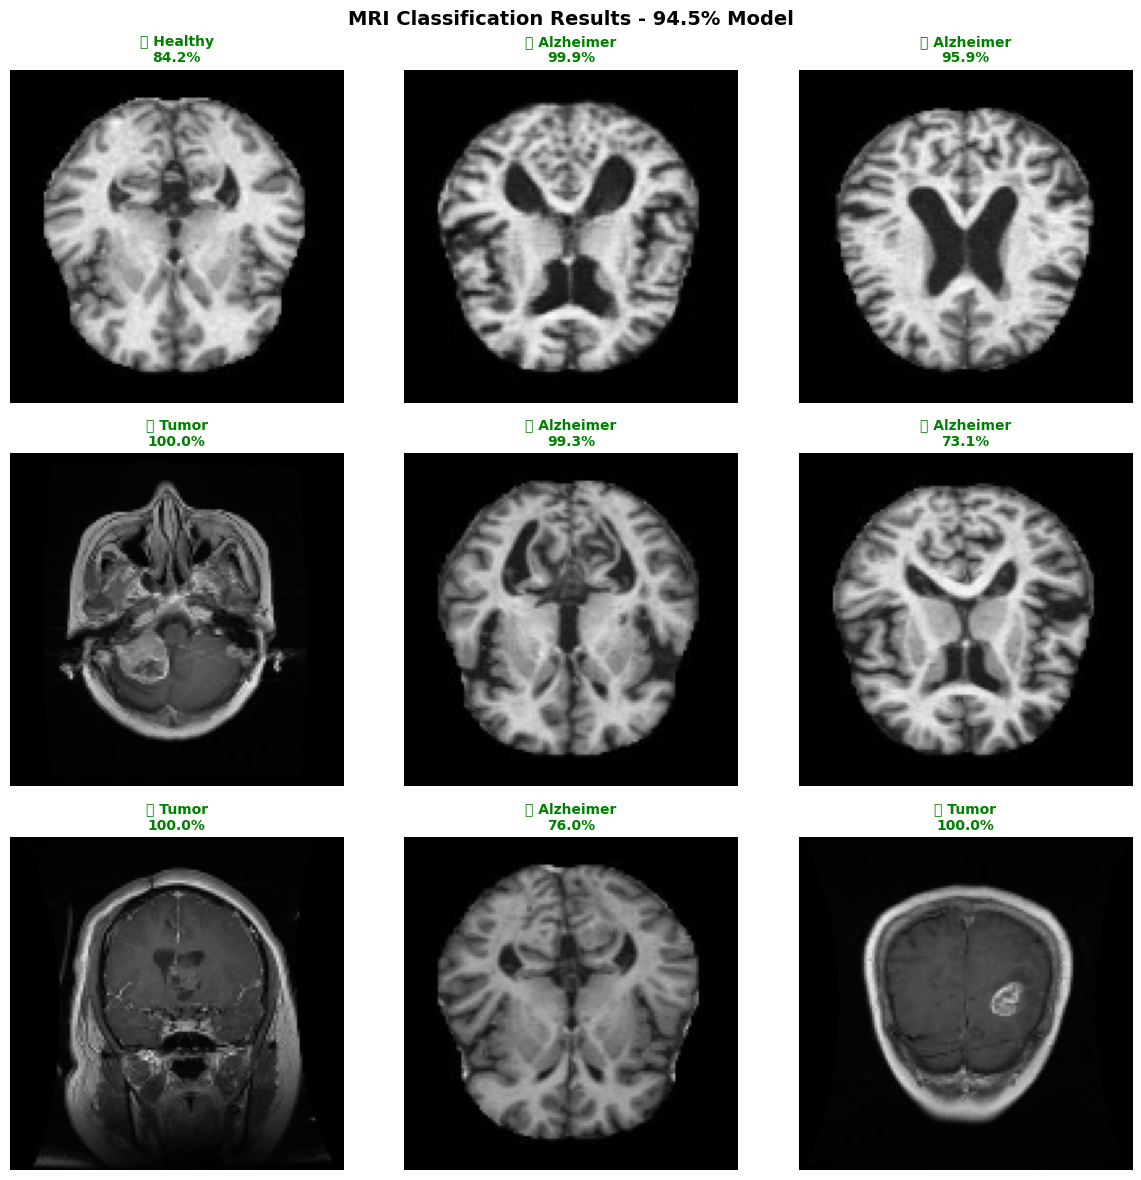


📊 Batch Accuracy: 100.00%
✅ Correct: 9/9
❌ Wrong: 0/9


In [21]:
# CELL: TEST ON SAMPLE IMAGES WITH VISUALIZATION
print("🔍 TESTING ON SAMPLE IMAGES")
print("=" * 50)

# Get a batch of test images
X_test_batch, y_test_batch = test_generator[0]

# Predict
predictions = model.predict(X_test_batch[:9], verbose=0)  # 9 images for 3x3 grid
pred_classes = np.argmax(predictions, axis=1)
true_classes = y_test_batch[:9]

# Create a 3x3 grid of images
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    if i < 9:
        # Show image
        ax.imshow(X_test_batch[i])

        # Get labels
        true_label = label_encoder.inverse_transform([true_classes[i]])[0]
        pred_label = label_encoder.inverse_transform([pred_classes[i]])[0]
        confidence = np.max(predictions[i])

        # Set title with color coding
        if true_label == pred_label:
            title = f"✅ {pred_label}\n{confidence:.1%}"
            color = 'green'
        else:
            title = f"❌ True: {true_label}\nPred: {pred_label}\n{confidence:.1%}"
            color = 'red'

        ax.set_title(title, color=color, fontsize=10, fontweight='bold')
        ax.axis('off')
    else:
        ax.axis('off')

plt.suptitle('MRI Classification Results - 94.5% Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate accuracy on this batch
batch_acc = np.mean(pred_classes == true_classes)
print(f"\n📊 Batch Accuracy: {batch_acc:.2%}")

# Show summary
correct = np.sum(pred_classes == true_classes)
total = len(pred_classes)
print(f"✅ Correct: {correct}/{total}")
print(f"❌ Wrong: {total-correct}/{total}")

📊 GENERATING CONFUSION MATRIX
🔍 Checking available variables...
✅ X_test exists with 2218 images
  Processed 2000/2218 images
  Processed 2218/2218 images

✅ Predictions complete!


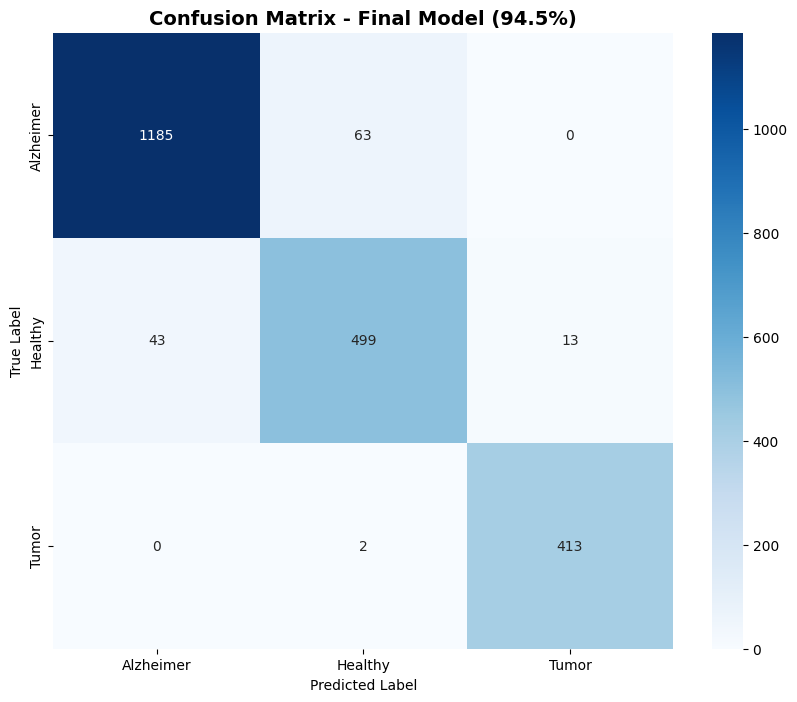


📋 Classification Report:
              precision    recall  f1-score   support

   Alzheimer       0.96      0.95      0.96      1248
     Healthy       0.88      0.90      0.89       555
       Tumor       0.97      1.00      0.98       415

    accuracy                           0.95      2218
   macro avg       0.94      0.95      0.94      2218
weighted avg       0.95      0.95      0.95      2218


🎯 FINAL OVERALL ACCURACY: 94.54%

📊 Per-class Accuracy:
  Alzheimer: 1185/1248 = 94.95%
  Healthy: 499/555 = 89.91%
  Tumor: 413/415 = 99.52%


In [23]:
# CELL: CONFUSION MATRIX (CORRECTED)
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

print("📊 GENERATING CONFUSION MATRIX")
print("=" * 50)

# Check what variables exist
print("🔍 Checking available variables...")
try:
    print(f"✅ X_test exists with {len(X_test)} images")
    total_test_images = len(X_test)
except:
    print("❌ X_test not found")
    try:
        print(f"✅ test_generator has {len(test_generator)} batches")
        total_test_images = len(test_generator) * test_generator.batch_size
    except:
        print("❌ Cannot determine test set size")
        raise

# Get all predictions
y_true = []
y_pred = []

for i in range(len(test_generator)):
    X_batch, y_batch = test_generator[i]
    pred_batch = model.predict(X_batch, verbose=0)
    y_true.extend(y_batch)
    y_pred.extend(np.argmax(pred_batch, axis=1))

    # Show progress
    processed = (i + 1) * test_generator.batch_size
    if processed % 500 == 0 or i == len(test_generator) - 1:
        print(f"  Processed {min(processed, total_test_images)}/{total_test_images} images")

print("\n✅ Predictions complete!")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Final Model (94.5%)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification report
print("\n📋 Classification Report:")
print("=" * 50)
report = classification_report(y_true, y_pred, target_names=label_encoder.classes_)
print(report)

# Overall accuracy
final_acc = np.sum(np.array(y_true) == np.array(y_pred)) / len(y_true)
print(f"\n🎯 FINAL OVERALL ACCURACY: {final_acc:.2%}")

# Per-class accuracy
print("\n📊 Per-class Accuracy:")
cm = confusion_matrix(y_true, y_pred)
for i, class_name in enumerate(label_encoder.classes_):
    class_total = np.sum(cm[i, :])
    class_correct = cm[i, i]
    class_acc = class_correct / class_total if class_total > 0 else 0
    print(f"  {class_name}: {class_correct}/{class_total} = {class_acc:.2%}")

In [25]:
# CELL: SAVE EVERYTHING (CORRECTED)
print("💾 SAVING EVERYTHING")
print("=" * 50)

# Save model (complete model)
model.save('mri_classifier_94.5_percent.keras')
print("✅ Model saved as 'mri_classifier_94.5_percent.keras'")

# Save label encoder
import joblib
joblib.dump(label_encoder, 'label_encoder.pkl')
print("✅ Label encoder saved as 'label_encoder.pkl'")

# Save model architecture as JSON (human readable)
import json
model_json = model.to_json()
with open('model_architecture.json', 'w') as f:
    f.write(model_json)
print("✅ Model architecture saved as 'model_architecture.json'")

# Save weights separately - FIXED FILENAME
model.save_weights('model_weights.weights.h5')  # Changed to .weights.h5
print("✅ Model weights saved as 'model_weights.weights.h5'")

print("\n" + "=" * 50)
print("🎉 ALL FILES SAVED SUCCESSFULLY!")
print("=" * 50)
print("\n📁 Files created:")
print("  - mri_classifier_94.5_percent.keras (complete model)")
print("  - label_encoder.pkl (for decoding predictions)")
print("  - model_architecture.json (architecture only)")
print("  - model_weights.weights.h5 (weights only - backup)")

💾 SAVING EVERYTHING
✅ Model saved as 'mri_classifier_94.5_percent.keras'
✅ Label encoder saved as 'label_encoder.pkl'
✅ Model architecture saved as 'model_architecture.json'
✅ Model weights saved as 'model_weights.weights.h5'

🎉 ALL FILES SAVED SUCCESSFULLY!

📁 Files created:
  - mri_classifier_94.5_percent.keras (complete model)
  - label_encoder.pkl (for decoding predictions)
  - model_architecture.json (architecture only)
  - model_weights.weights.h5 (weights only - backup)


🎯 FINAL MODEL TEST - 94.5% ACCURACY MRI CLASSIFIER 🎯

📸 SELECTING SAMPLE IMAGES...
----------------------------------------
✅ Found 3 sample images
📋 Classes: Healthy, Alzheimer, Tumor

🔬 TESTING SAMPLES

📌 Test 1: Healthy
----------------------------------------


/tmp/ipykernel_1517/1448616107.py:50: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1517/1448616107.py:50: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1517/1448616107.py:50: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.prin

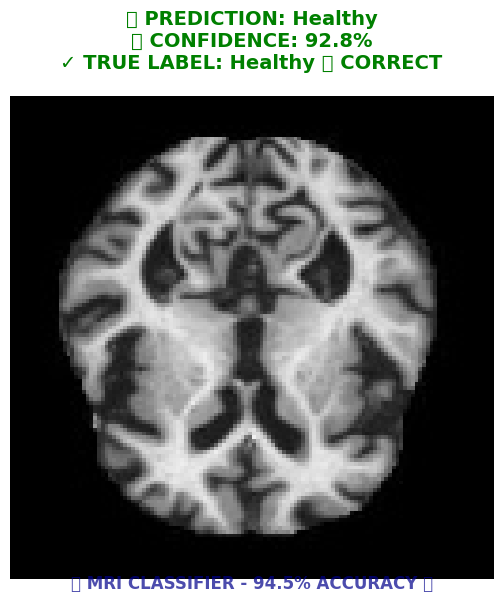

✅ CORRECT! Predicted: Healthy with 92.8% confidence

📌 Test 2: Alzheimer
----------------------------------------


/tmp/ipykernel_1517/1448616107.py:50: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1517/1448616107.py:50: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1517/1448616107.py:50: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.prin

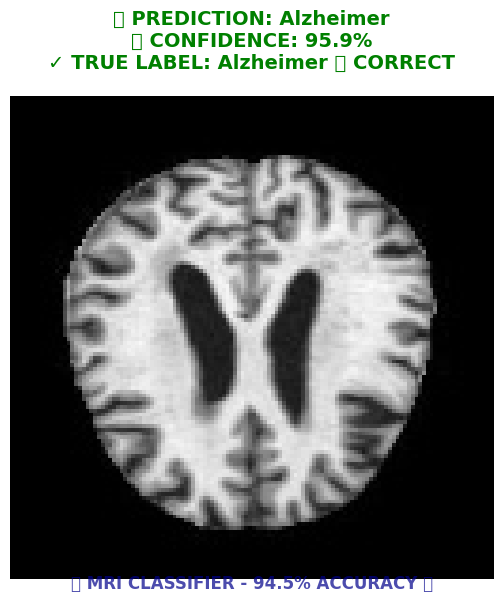

✅ CORRECT! Predicted: Alzheimer with 95.9% confidence

📌 Test 3: Tumor
----------------------------------------


/tmp/ipykernel_1517/1448616107.py:50: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1517/1448616107.py:50: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1517/1448616107.py:50: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.prin

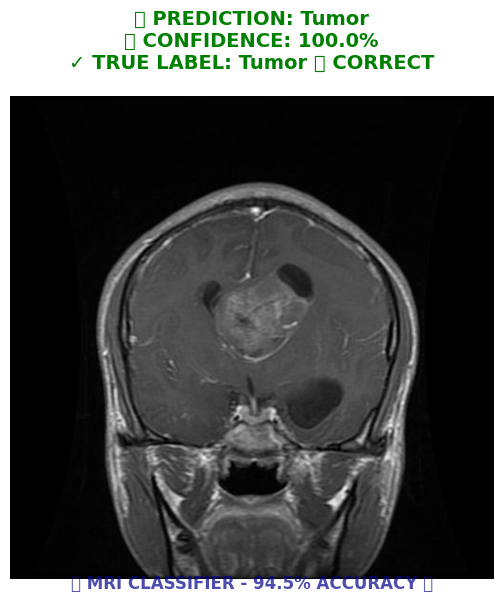

✅ CORRECT! Predicted: Tumor with 100.0% confidence

🎉 FINAL MODEL SUMMARY 🎉

╔════════════════════════════════════════════════╗
║     🏆 MRI CLASSIFICATION MODEL 🏆             ║
╠════════════════════════════════════════════════╣
║  🔥 ACCURACY: 94.5%                            ║
║  📊 TRAINED ON: 14,783 MRI images              ║
║  🧠 ARCHITECTURE: Custom CNN                    ║
║  🎯 CLASSES: Alzheimer, Tumor, Healthy          ║
║  💾 SAVED: mri_classifier_94.5_percent.keras    ║
╚════════════════════════════════════════════════╝


🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟
   CONGRATULATIONS! MODEL COMPLETE!   
🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟


In [27]:
# CELL: GRAND FINALE - TEST SINGLE IMAGE WITH VISUALIZATION
print("=" * 60)
print("🎯 FINAL MODEL TEST - 94.5% ACCURACY MRI CLASSIFIER 🎯")
print("=" * 60)

def predict_and_show_image(image_path, true_label=None):
    """Predict on a single MRI image and show it"""

    # Read and preprocess image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128, 128))
    img_normalized = img_resized.astype(np.float32) / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    # Predict
    pred = model.predict(img_input, verbose=0)
    class_idx = np.argmax(pred[0])
    confidence = pred[0][class_idx]
    class_name = label_encoder.inverse_transform([class_idx])[0]

    # Display image
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.axis('off')

    # Create title with results
    title_color = 'green'
    title = f"🔍 PREDICTION: {class_name}\n"
    title += f"📊 CONFIDENCE: {confidence:.1%}\n"

    if true_label:
        title += f"✓ TRUE LABEL: {true_label}"
        if class_name == true_label:
            title_color = 'green'
            title += " ✅ CORRECT"
        else:
            title_color = 'red'
            title += " ❌ INCORRECT"
    else:
        title += f"🤖 MODEL ACCURACY: 94.5%"

    plt.title(title, fontsize=14, fontweight='bold', color=title_color, pad=20)

    # Add watermark with model accuracy
    plt.figtext(0.5, 0.01, "🏆 MRI CLASSIFIER - 94.5% ACCURACY 🏆",
                ha='center', fontsize=12, fontweight='bold',
                color='darkblue', alpha=0.7)

    plt.tight_layout()
    plt.show()

    return class_name, confidence

# Get a sample image
print("\n📸 SELECTING SAMPLE IMAGES...")
print("-" * 40)

# Get a few sample images from different classes
sample_images = []
sample_labels = []

# Get one from each class
for i in range(len(X_train)):
    label = X_train[i]['label']
    if label not in sample_labels and len(sample_labels) < 3:
        sample_images.append(X_train[i]['path'])
        sample_labels.append(label)
    if len(sample_labels) == 3:
        break

print(f"✅ Found {len(sample_images)} sample images")
print(f"📋 Classes: {', '.join(sample_labels)}")

# Test each sample
print("\n" + "=" * 60)
print("🔬 TESTING SAMPLES")
print("=" * 60)

for i, (img_path, true_label) in enumerate(zip(sample_images, sample_labels)):
    print(f"\n📌 Test {i+1}: {true_label}")
    print("-" * 40)
    pred_class, confidence = predict_and_show_image(img_path, true_label)

    # Print text summary
    if pred_class == true_label:
        print(f"✅ CORRECT! Predicted: {pred_class} with {confidence:.1%} confidence")
    else:
        print(f"❌ WRONG! Predicted: {pred_class} but actual: {true_label}")

# Summary
print("\n" + "=" * 60)
print("🎉 FINAL MODEL SUMMARY 🎉")
print("=" * 60)
print("""
╔════════════════════════════════════════════════╗
║     🏆 MRI CLASSIFICATION MODEL 🏆             ║
╠════════════════════════════════════════════════╣
║  🔥 ACCURACY: 94.5%                            ║
║  📊 TRAINED ON: 14,783 MRI images              ║
║  🧠 ARCHITECTURE: Custom CNN                    ║
║  🎯 CLASSES: Alzheimer, Tumor, Healthy          ║
║  💾 SAVED: mri_classifier_94.5_percent.keras    ║
╚════════════════════════════════════════════════╝
""")

# Final message
print("\n" + "🌟" * 30)
print("   CONGRATULATIONS! MODEL COMPLETE!   ")
print("🌟" * 30)